<a href="https://colab.research.google.com/github/sreuter1/transfer_learning/blob/main/ViT_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Needed Libraries - Routing to Proper Device

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader, random_split, Dataset
from PIL import Image

print("torch:", torch.__version__)
device = "cuda"  # Change device in the runtime settings - to GPU T4
print(torch.cuda.is_available())
print("device:", device)

def set_seed(seed: int = 42):                                                                       # Here for reproducability
    """Make results as reproducible as possible across runs."""
    import os, random
    import numpy as np
    import torch

    # os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

set_seed(42)                                                                                        # Here for reproducability


torch: 2.11.0+cu128
True
device: cuda
hello


Importing From Kaggle API - Get Kaggle key first - Already Downloaded

In [2]:
!export KAGGLE_API_TOKEN=KGAT_6e0db17c19cd9ec6f55621b971c1014d

!mkdir -p ~/.kaggle && echo KGAT_6e0db17c19cd9ec6f55621b971c1014d > ~/.kaggle/access_token && chmod 666 ~/.kaggle/access_token

!kaggle competitions list

!export KAGGLE_API_TOKEN=KGAT_d77bc5e53c781f271763950cf13abd1c

!mkdir -p ~/.kaggle && echo KGAT_d77bc5e53c781f271763950cf13abd1c > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [3]:
# Code that kaggle said to run to get access to the competition files
import kagglehub

# Download latest version
path = kagglehub.competition_download('ucsc-cse-144-spring-2026-final-project')

print("Path to competition files:", path)

100%|██████████| 120M/120M [00:07<00:00, 16.1MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/ucsc-cse-144-spring-2026-final-project


Data Pipeline - Dataset and DataLoader - IN PROGRESS

In [26]:

batch_size = 32  # For now, can change to 64?
num_workers = 0                                                                 # Here for reproducability
mean=[0.485, 0.456, 0.406]                                                      # ImageNet stats - that is what the model was trained on
std=[0.229, 0.224, 0.225]
val_p = 0.2 # portion of training data


class UnlabeledDataset(Dataset):
  def __init__(self, root, transform=None):
      self.root   = root
      self.transform = transform
      self.images    = sorted(os.listdir(root))

  def __len__(self):
      return len(self.images)

  def __getitem__(self, idx):
      img_path = os.path.join(self.root, self.images[idx])
      image    = Image.open(img_path).convert('RGB')
      if self.transform:
          image = self.transform(image)
      return image, self.images[idx]

train_path = path + '/train'
test_path = path + '/test'


#data augmentation to expand training dataset
train_tf = v2.Compose([
           v2.ToImage(),
           v2.ToDtype(torch.uint8, scale=True),
           v2.Resize((224, 224)),
           v2.RandomResizedCrop(size=(224, 224), antialias=True),   # Augmentation
           v2.RandomHorizontalFlip(p=0.5),                          # Augmentation
           v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),   #Augmentation
           v2.ToDtype(torch.float32, scale=True),
           v2.Normalize(mean, std)
])

test_tf = v2.Compose([
          v2.ToImage(),
          v2.Resize((224, 224)),
          v2.Normalize(mean, std)
])

train_set = datasets.ImageFolder(root=train_path, transform=train_tf)
val_set   = datasets.ImageFolder(root=train_path,  transform=test_tf)
test_set   = UnlabeledDataset(root=test_path,  transform=test_tf)

train_size = int((1-val_p) * len(train_set))
val_size   = len(train_set) - train_size

train_set, val_set = random_split(train_set, [train_size, val_size])

train_loader = DataLoader(dataset=train_set,
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=0
)
val_loader =   DataLoader(dataset=val_set,
                          batch_size=batch_size,
                          shuffle=False,
                          num_workers=0
)
test_loader =  DataLoader(dataset=test_set,
                          batch_size=batch_size,
                          shuffle=False,
                          num_workers=0
)

print("train/val/test:", len(train_set), len(val_set), len(test_set))

train/val/test: 863 216 1036


Defining the ViT model

In [27]:
import torchvision.models as models
model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)


#freeze weights
for param in model.parameters():
  param.requires_grad = False


#replace classifier head
number_classes = 100
model.heads.head = nn.Linear(model.heads.head.in_features, number_classes)

model = model.to(device)

#verification
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable}, Total: {total}")



Trainable: 76900, Total: 85875556


Training Function

In [29]:
# Q3.1: Training function
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adagrad(model.parameters(), lr=0.01)

def train_one_epoch(model, loader):
    """Train for one epoch and return (avg_loss, accuracy)."""
    # - Set model to training mode
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    # - Loop through batches in the loader
    for batch, (X,y) in enumerate(loader):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()           #   * Zero gradients
        prediction = model(X)           #   * Forward pass
        loss = criterion(prediction,y)  #   * Compute loss
        loss.backward()                 #   * Backward pass
        optimizer.step()                #   * Optimizer step

        total_loss += loss.item()
        predicted = prediction.argmax(dim=1)
        correct+= (predicted == y).sum().item()
        total += y.size(0)
    avg_loss = total_loss/len(loader)
    accuracy = correct/total

    # - Track total loss and accuracy (IMPORTANT: get predicted labels and compare with targets)
    # - Return average loss and accuracy
    return avg_loss, accuracy
    # ========== YOUR CODE ENDS HERE ============

Validation Function

In [31]:
# Q3.2: Validation function
@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model and return (avg_loss, accuracy)."""

    model.eval()                                 # - Set model to evaluation mode

    total_loss = 0.0                             # - Creating variables for loss and accuracy calculations
    correct = 0
    total = 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)        # - Loop through batches without computing gradients
        prediction = model(X)
        loss = criterion(prediction,y)
        total_loss += loss.item()
        predicted = prediction.argmax(dim=1)
        correct+= (predicted == y).sum().item()
        total += y.size(0)
    avg_loss = total_loss/len(loader)            # computing loss and accuracy
    accuracy = correct/total

    return avg_loss, accuracy

Training Loop

In [32]:
# Q3.3: Training loop with checkpointing
epochs = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_epoch = -1
ckpt_path = "./checkpoints/best_transfer.ViT.pt"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

# - Loop through epochs
for i in range(epochs):
    # - Each epoch: train, validate, log metrics
    train_loss, train_accuracy = train_one_epoch(model, train_loader)
    valid_loss, valid_accuracy = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_accuracy)
    history["val_loss"].append(valid_loss)
    history["val_acc"].append(valid_accuracy)

    # - Track best validation accuracy and save checkpoint when improved
    if (valid_accuracy > best_val_acc):
        best_epoch = i
        best_val_acc = valid_accuracy
        torch.save(
            {"model_state_dict": model.state_dict(), "epoch": i},
            ckpt_path
        )

    # - Print training and validation metrics each epoch
    print("train_loss:", train_loss, "train_accuracy:", train_accuracy)
    print("valid_loss:", valid_loss, "valid_accuracy:", valid_accuracy)

# ========== YOUR CODE ENDS HERE ============

print("Best val acc:", best_val_acc, "at epoch", best_epoch)
print("Saved to:", ckpt_path)

train_loss: 3.202086837203414 train_accuracy: 0.2526071842410197
valid_loss: 2.4841930866241455 valid_accuracy: 0.3148148148148148
train_loss: 1.8457638246041757 train_accuracy: 0.5144843568945539
valid_loss: 2.2205789600099837 valid_accuracy: 0.37962962962962965
train_loss: 1.5032722376011036 train_accuracy: 0.6048667439165701
valid_loss: 2.1369410923549106 valid_accuracy: 0.4074074074074074
train_loss: 1.2809380844787315 train_accuracy: 0.6906141367323291
valid_loss: 1.9157134294509888 valid_accuracy: 0.46296296296296297
train_loss: 1.156520805977009 train_accuracy: 0.7497103128621089
valid_loss: 1.8638926233564104 valid_accuracy: 0.4675925925925926
train_loss: 1.0854188292114824 train_accuracy: 0.779837775202781
valid_loss: 1.9081669705254691 valid_accuracy: 0.47685185185185186
train_loss: 1.02953334207888 train_accuracy: 0.8018539976825029
valid_loss: 1.8645197323390417 valid_accuracy: 0.5185185185185185
train_loss: 0.9719296362664964 train_accuracy: 0.8111239860950173
valid_loss: 

Curves

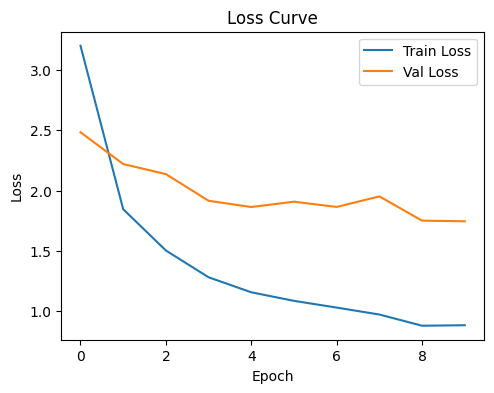

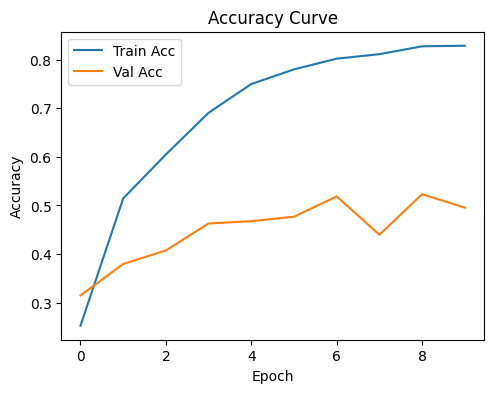

In [33]:
# Q3.4: Plot curves
# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Create two plots: one for loss (train vs val), one for accuracy (train vs val)
# - Use the history dictionary to get the values
# - Add labels, legends, and display the plots

# Loss ------------------------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy --------------------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'],   label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# ========== YOUR CODE ENDS HERE ============

Testing

In [34]:
# Q4: Test evaluation
# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Load the best checkpoint (it's a dictionary with 'model_state_dict' and 'epoch')
# - Load the model state from the checkpoint
# - Evaluate on the test set
# - Print test loss and accuracy

checkpoint = torch.load(ckpt_path)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Evaluate the best model state from the checkpoint
test_loss, test_acc = evaluate(model, val_loader)
# ========== YOUR CODE ENDS HERE ============

print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

Test loss: 1.7972 | Test acc: 0.5046
